Week 13. ML-блок для сквозного проекта  
Проект: variant_05, погодные данные Open-Meteo по Нью-Йорку.

Часть 0. Почему качество «под 99%» может быть подозрительным

Если модель фактически «подглядывает» в данные заранее, её нельзя честно оценить. В неправильном примере целевая переменная попадает в признаки, а StandardScaler обучается на всём датасете ещё до разделения на train и test. Метрика в такой схеме получается завышенной и не показывает реальное качество на новых данных.

Правило: целевой признак не кладём в X, а любые преобразования сначала обучаем только на train и затем применяем к test через transform.

Часть 1. Выбор сценария

В данных проекта нет отдельной размеченной целевой переменной для полноценной классификации, поэтому выбран вариант B — поиск аномалий. Это позволяет показать простой ML/аналитический подход без искусственного придумывания target.

In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NORMALIZED_DIR = PROJECT_ROOT / "data" / "normalized" / "variant_05"
OUTPUT_DIR = PROJECT_ROOT / "docs" / "ml"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT.name)
print("NORMALIZED_DIR exists:", NORMALIZED_DIR.exists())
print("OUTPUT_DIR ready:", OUTPUT_DIR.exists())

PROJECT_ROOT: end-to-end-project
NORMALIZED_DIR exists: True
OUTPUT_DIR ready: True


In [8]:
files = sorted(NORMALIZED_DIR.glob("*.csv"))
print("Найдено normalized-файлов:", len(files))

if not files:
    raise FileNotFoundError("Не найдены файлы в data/normalized/variant_05")

source_path = files[-1]

df = pd.read_csv(source_path, parse_dates=["time"])
df = df.sort_values("time").reset_index(drop=True)
df.head()

Найдено normalized-файлов: 46


,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,latitude,longitude,elevation,city_id,city_name,date,hour,is_rainy
0,2026-06-10 00:00:00+00:00,21.9,59,0.0,11.8,40.710335,-73.99308,32.0,US_NYC,Нью-Йорк,2026-06-10,0,False
1,2026-06-10 01:00:00+00:00,21.2,60,0.0,11.8,40.710335,-73.99308,32.0,US_NYC,Нью-Йорк,2026-06-10,1,False
2,2026-06-10 02:00:00+00:00,20.7,62,0.0,9.7,40.710335,-73.99308,32.0,US_NYC,Нью-Йорк,2026-06-10,2,False
3,2026-06-10 03:00:00+00:00,20.7,64,0.0,10.3,40.710335,-73.99308,32.0,US_NYC,Нью-Йорк,2026-06-10,3,False
4,2026-06-10 04:00:00+00:00,20.5,63,0.0,9.3,40.710335,-73.99308,32.0,US_NYC,Нью-Йорк,2026-06-10,4,False


In [9]:
print(df.columns.tolist())

['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'latitude', 'longitude', 'elevation', 'city_id', 'city_name', 'date', 'hour', 'is_rainy']


In [13]:
metric_col = "temperature_2m"

q1 = df[metric_col].quantile(0.25)
q3 = df[metric_col].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.0 * iqr
upper_bound = q3 + 1.0 * iqr

mean = df[metric_col].mean()
std = df[metric_col].std(ddof=0)

df_result = df.copy()
df_result["z_score"] = (df_result[metric_col] - mean) / std
df_result["is_anomaly"] = (
    (df_result[metric_col] < lower_bound) |
    (df_result[metric_col] > upper_bound)
)

df_result["distance_from_iqr_bound"] = 0.0

lower_mask = df_result[metric_col] < lower_bound
upper_mask = df_result[metric_col] > upper_bound

df_result.loc[lower_mask, "distance_from_iqr_bound"] = (
    lower_bound - df_result.loc[lower_mask, metric_col]
)
df_result.loc[upper_mask, "distance_from_iqr_bound"] = (
    df_result.loc[upper_mask, metric_col] - upper_bound
)

df_result["iqr_lower_bound"] = lower_bound
df_result["iqr_upper_bound"] = upper_bound

anomalies = df_result[df_result["is_anomaly"]].copy()
anomalies = anomalies.sort_values("distance_from_iqr_bound", ascending=False)

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"Аномалий: {len(anomalies)} из {len(df_result)}")

anomalies[[metric_col, "z_score", "distance_from_iqr_bound"]].head()

Q1: 20.85
Q3: 27.02
IQR: 6.18
Нижняя граница: 14.67
Верхняя граница: 33.20
Аномалий: 0 из 24


,temperature_2m,z_score,distance_from_iqr_bound


In [14]:
if "date" not in anomalies.columns:
    anomalies["date"] = anomalies["time"].dt.date

if "hour" not in anomalies.columns:
    anomalies["hour"] = anomalies["time"].dt.hour

anomalies_out = anomalies[
    [
        "time",
        "date",
        "hour",
        metric_col,
        "z_score",
        "iqr_lower_bound",
        "iqr_upper_bound",
        "distance_from_iqr_bound",
    ]
].copy()

anomalies_out.to_csv(OUTPUT_DIR / "anomalies_top.csv", index=False)
anomalies_out.head()

,time,date,hour,temperature_2m,z_score,iqr_lower_bound,iqr_upper_bound,distance_from_iqr_bound


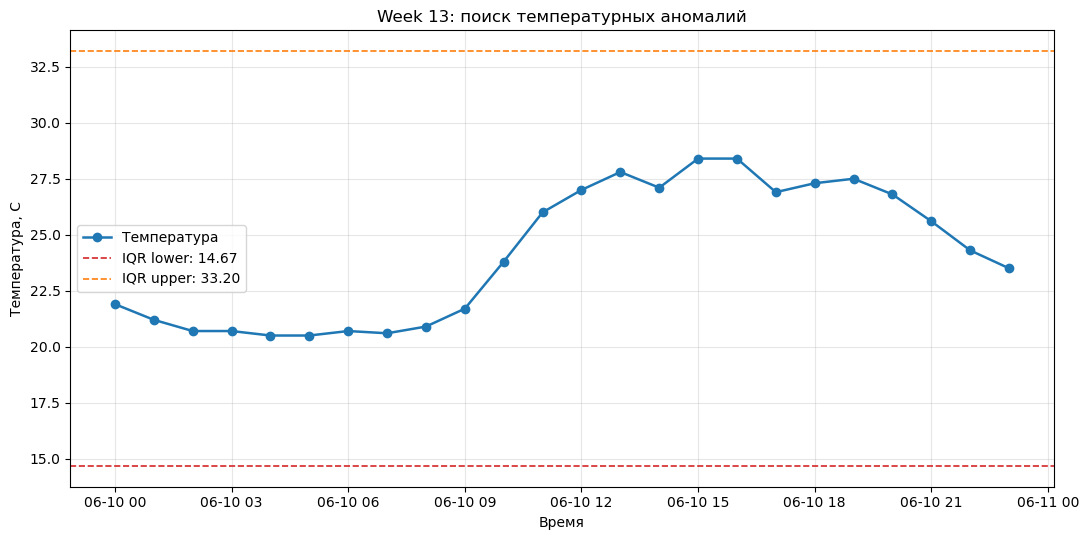

In [15]:
plot_path = OUTPUT_DIR / "metrics.png"

plt.figure(figsize=(11, 5.5))
plt.plot(
    df_result["time"],
    df_result[metric_col],
    marker="o",
    linewidth=1.8,
    label="Температура"
)

plt.axhline(
    lower_bound,
    color="tab:red",
    linestyle="--",
    linewidth=1.2,
    label=f"IQR lower: {lower_bound:.2f}"
)

plt.axhline(
    upper_bound,
    color="tab:orange",
    linestyle="--",
    linewidth=1.2,
    label=f"IQR upper: {upper_bound:.2f}"
)

if not anomalies.empty:
    plt.scatter(
        anomalies["time"],
        anomalies[metric_col],
        color="tab:red",
        s=90,
        zorder=5,
        label="Аномалия"
    )

plt.title("Week 13: поиск температурных аномалий")
plt.xlabel("Время")
plt.ylabel("Температура, C")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(plot_path, dpi=160)
plt.show()

Вывод

Метод IQR позволяет быстро найти подозрительные значения температуры в часовом ряду. Такой подход полезен как простой мониторинг аномалий, но для более надёжных выводов желательно использовать более длинную историю наблюдений и дополнительные погодные признаки.

In [16]:
check = pd.read_csv(OUTPUT_DIR / "anomalies_top.csv")
print("Строк в anomalies_top.csv:", len(check))
check.head()

Строк в anomalies_top.csv: 0


,time,date,hour,temperature_2m,z_score,iqr_lower_bound,iqr_upper_bound,distance_from_iqr_bound
